# Experiment 5.5.1.1 — Routing Diagnostics

**Analysis-only notebook.** It reads finalized Exp5.5.1.1 CSV/JSON artifacts and never runs diagnostics, retrains models, launches Slurm, or regenerates missing artifacts.

Scientific question: is Exp5.5.1 limited mainly by diffuse q or by weak expert specialization?

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    path = start.resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'AGENTS.md').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('Repository root not found')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_5_5_1_1_routing_diagnostics' / 'routing_diagnostics_v1'
required = {
    'confidence': ROOT / 'confidence_metrics.csv',
    'confidence_summary': ROOT / 'confidence_summary.csv',
    'temperature': ROOT / 'temperature_sweep.csv',
    'temperature_summary': ROOT / 'temperature_summary.csv',
    'alignment': ROOT / 'temperature_alignment.csv',
    'weight': ROOT / 'expert_weight_similarity.csv',
    'functional': ROOT / 'expert_functional_diversity.csv',
    'expert_summary': ROOT / 'expert_summary.csv',
    'manifest': ROOT / 'manifest.json',
}
missing = [path for path in required.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f'Incomplete Exp5.5.1.1 finalization; missing: {missing}')
confidence = pd.read_csv(required['confidence'])
confidence_summary = pd.read_csv(required['confidence_summary'])
temperature = pd.read_csv(required['temperature'])
temperature_summary = pd.read_csv(required['temperature_summary'])
alignment = pd.read_csv(required['alignment'])
weight = pd.read_csv(required['weight'])
functional = pd.read_csv(required['functional'])
expert_summary = pd.read_csv(required['expert_summary'])
manifest = json.loads(required['manifest'].read_text())
manifest

{'diagnostic_only': True,
 'experiment_id': 'experiment_5_5_1_1_routing_diagnostics',
 'functional_max_points': 50000,
 'hard_variant': 'hard_top1',
 'multi_cpu_policy': '5 independent seed diagnostic tasks -> one artifact-only finalizer',
 'no_temperature_selection': True,
 'no_training': True,
 'notebook_policy': 'analysis-only; reads finalized CSV/JSON artifacts and never runs diagnostics or regenerates missing artifacts',
 'protocol_version': 'routing_diagnostics_v1',
 'seeds': [11, 23, 37, 53, 71],
 'shuffle_replicates': 5,
 'source_experiment_id': 'experiment_5_5_1_regularized_semantic_when',
 'source_protocol_version': 'regularized_semantic_when_v1',
 'temperatures': [1.0, 0.8, 0.6, 0.4, 0.25],
 'test_policy': 'val/test are reported for post-hoc diagnosis only; no temperature or architecture is selected in Exp5.5.1.1'}

## 1. q confidence
Inspect raw selected Exp5.5.1 q before any post-hoc sharpening.

,fraction_max_q_ge_0.3,fraction_max_q_ge_0.4,fraction_max_q_ge_0.5,fraction_max_q_ge_0.6,mean_effective_states,mean_entropy,mean_max_q,mean_top1_top2_margin,median_max_q,median_top1_top2_margin,n_timesteps,normalized_entropy,p10_max_q,p25_max_q,p75_max_q,p90_max_q,seed,split
0,0.4276,0.1820,0.0591,0.0229,6.2344,1.8153,0.3068,0.1050,0.2800,0.0549,11391,0.8730,0.1975,0.2316,0.3653,0.4598,11,val
1,0.4705,0.2044,0.0717,0.0139,6.2263,1.8157,0.3135,0.1159,0.2924,0.0682,12072,0.8732,0.1975,0.2322,0.3741,0.4740,11,test
2,0.3055,0.0967,0.0279,0.0039,6.7556,1.9006,0.2696,0.0824,0.2490,0.0443,11391,0.9140,0.1796,0.1899,0.3186,0.3977,23,val
3,0.3538,0.1366,0.0395,0.0052,6.6024,1.8763,0.2842,0.0963,0.2637,0.0578,12072,0.9023,0.1819,0.2032,0.3403,0.4285,23,test
4,0.5069,0.2870,0.0989,0.0030,6.2954,1.8280,0.3286,0.1554,0.3033,0.1093,11391,0.8791,0.2031,0.2361,0.4159,0.4995,37,val
5,0.5311,0.2859,0.1024,0.0059,6.2107,1.8142,0.3326,0.1567,0.3113,0.1146,12072,0.8724,0.2057,0.2421,0.4193,0.5024,37,test
6,0.0075,0.0000,0.0000,0.0000,7.5966,2.0265,0.1891,0.0303,0.1817,0.0167,11391,0.9746,0.1488,0.1500,0.2146,0.2468,53,val
7,0.0146,0.0000,0.0000,0.0000,7.5028,2.0139,0.1932,0.0270,0.1882,0.0162,12072,0.9685,0.1493,0.1575,0.2181,0.2463,53,test
8,0.1257,0.0190,0.0012,0.0000,7.3891,1.9952,0.2095,0.0419,0.1865,0.0188,11391,0.9595,0.1479,0.1502,0.2437,0.3150,71,val
9,0.2005,0.0511,0.0030,0.0000,7.1279,1.9561,0.2347,0.0560,0.2164,0.0316,12072,0.9407,0.1486,0.1643,0.2821,0.3551,71,test


split,test,val
metric,,
fraction_max_q_ge_0.3,0.3141,0.2747
fraction_max_q_ge_0.4,0.1356,0.1169
fraction_max_q_ge_0.5,0.0433,0.0374
fraction_max_q_ge_0.6,0.0050,0.0060
mean_effective_states,6.7340,6.8542
mean_entropy,1.8952,1.9131
mean_max_q,0.2717,0.2607
mean_top1_top2_margin,0.0904,0.0830
median_max_q,0.2544,0.2401


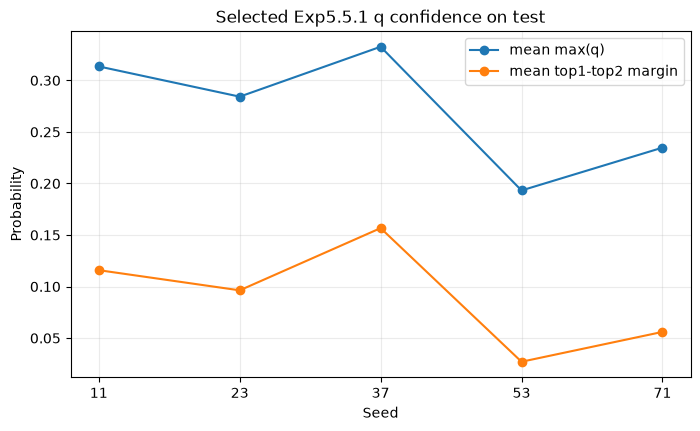

In [2]:
display(confidence.round(4))
display(confidence_summary.pivot(index='metric', columns='split', values='mean').round(4))

test_conf = confidence[confidence['split'] == 'test'].sort_values('seed')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(test_conf['seed'].astype(str), test_conf['mean_max_q'], marker='o', label='mean max(q)')
ax.plot(test_conf['seed'].astype(str), test_conf['mean_top1_top2_margin'], marker='o', label='mean top1-top2 margin')
ax.set_xlabel('Seed')
ax.set_ylabel('Probability')
ax.set_title('Selected Exp5.5.1 q confidence on test')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 2. Post-hoc routing sharpness
No temperature is selected here. The table/plots are diagnostic only.

,split,variant,mean_balanced_accuracy,sd_balanced_accuracy,sem_balanced_accuracy,mean_delta_balanced_accuracy_vs_tau1,nonnegative_delta_seed_count,mean_max_q,mean_top1_top2_margin,mean_entropy,mean_effective_states
0,val,tau_1.00,0.5522,0.0142,0.0063,0.0000,5,0.2607,0.0830,1.9131,6.8542
1,val,tau_0.80,0.5366,0.0144,0.0064,-0.0156,0,0.2982,0.1129,1.8350,6.4153
2,val,tau_0.60,0.5296,0.0366,0.0164,-0.0226,2,0.3568,0.1637,1.6978,5.7456
3,val,tau_0.40,0.4973,0.0444,0.0198,-0.0549,1,0.4519,0.2546,1.4488,4.7350
4,val,tau_0.25,0.4406,0.0506,0.0226,-0.1116,0,0.5643,0.3745,1.1383,3.6763
5,val,hard_top1,0.3619,0.0666,0.0298,-0.1903,0,1.0000,1.0000,0.0000,1.0000
6,test,tau_1.00,0.5199,0.0300,0.0134,0.0000,5,0.2717,0.0904,1.8952,6.7340
7,test,tau_0.80,0.5175,0.0383,0.0171,-0.0024,3,0.3121,0.1231,1.8088,6.2544
8,test,tau_0.60,0.5016,0.0345,0.0154,-0.0184,1,0.3748,0.1782,1.6583,5.5357
9,test,tau_0.40,0.4811,0.0306,0.0137,-0.0388,0,0.4745,0.2755,1.3916,4.4888


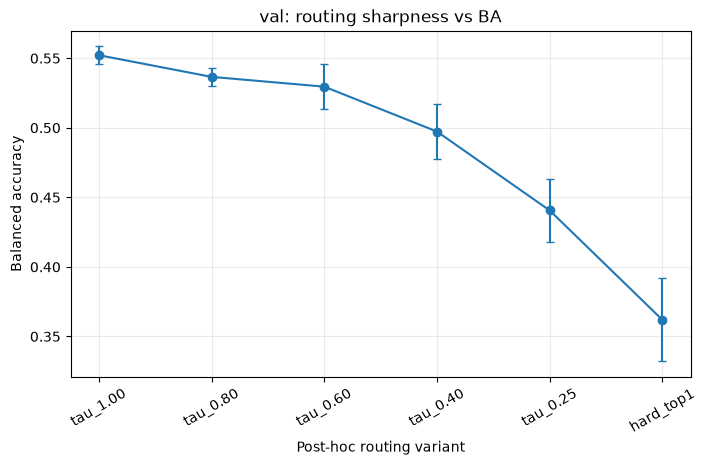

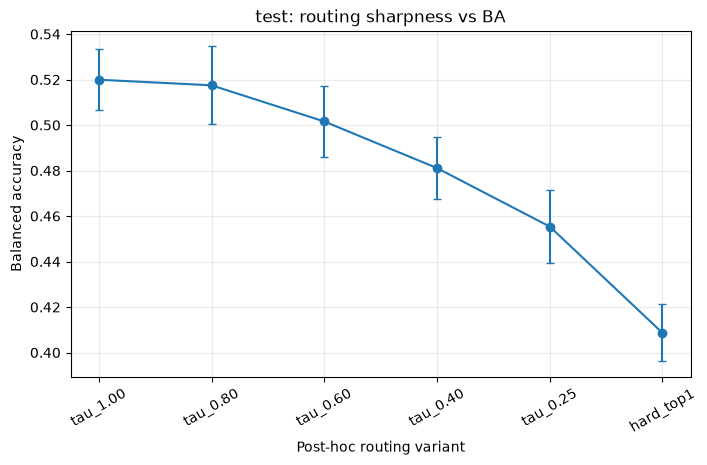

In [3]:
display(temperature_summary.round(4))
order = ['tau_1.00', 'tau_0.80', 'tau_0.60', 'tau_0.40', 'tau_0.25', 'hard_top1']
for split in ('val', 'test'):
    frame = temperature_summary[temperature_summary['split'] == split].set_index('variant').reindex(order)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.errorbar(order, frame['mean_balanced_accuracy'], yerr=frame['sem_balanced_accuracy'], marker='o', capsize=3)
    ax.set_xlabel('Post-hoc routing variant')
    ax.set_ylabel('Balanced accuracy')
    ax.set_title(f'{split}: routing sharpness vs BA')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.25)
    plt.show()

## 3. Does sharpening increase dependence on correct q/WHAT alignment?

,index,split,variant,mean,std
0,0,test,hard_top1,-0.0093,0.0178
1,1,test,tau_0.25,-0.0114,0.0347
2,2,test,tau_0.40,-0.0013,0.0364
3,3,test,tau_0.60,-0.0026,0.0350
4,4,test,tau_0.80,0.0031,0.0287
5,5,test,tau_1.00,0.0057,0.0123
6,6,val,hard_top1,-0.0180,0.0373
7,7,val,tau_0.25,0.0087,0.0446
8,8,val,tau_0.40,0.0281,0.0472
9,9,val,tau_0.60,0.0315,0.0369


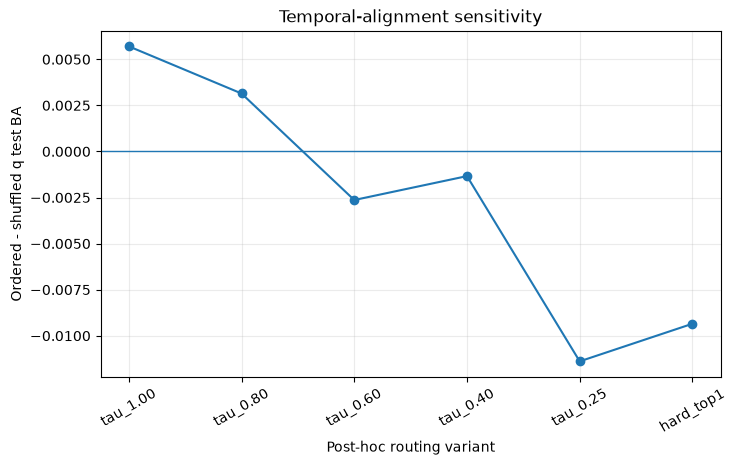

In [4]:
align_summary = alignment.groupby(['split', 'variant'], as_index=False)['ordered_minus_shuffled_balanced_accuracy'].agg(['mean', 'std']).reset_index()
display(align_summary.round(4))
test_align = align_summary[align_summary['split'] == 'test'].set_index('variant').reindex(order)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(order, test_align['mean'], marker='o')
ax.axhline(0.0, linewidth=1)
ax.set_xlabel('Post-hoc routing variant')
ax.set_ylabel('Ordered - shuffled q test BA')
ax.set_title('Temporal-alignment sensitivity')
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.25)
plt.show()

## 4. Expert specialization
Weight-space diversity and functional diversity are inspected separately.

,scope,split,metric,mean,sd,sem
0,weight,all,weight_cosine_similarity,0.2723,0.0855,0.0383
1,weight,all,weight_l2_distance,1.5959,0.0235,0.0105
2,weight,all,weight_relative_l2_distance,1.2049,0.0695,0.0311
3,functional,val,mean_evidence_l1_difference,2.9412,0.3709,0.1659
4,functional,val,mean_evidence_l2_difference,1.0456,0.1383,0.0619
5,functional,val,mean_relative_evidence_l2_difference,1.2267,0.0616,0.0275
6,functional,val,mean_evidence_cosine_similarity,0.2449,0.0769,0.0344
7,functional,val,top_support_disagreement_rate,0.8649,0.0139,0.0062
8,functional,val,active_what_fraction,0.8013,0.0180,0.0081
9,functional,test,mean_evidence_l1_difference,3.2890,0.4410,0.1972


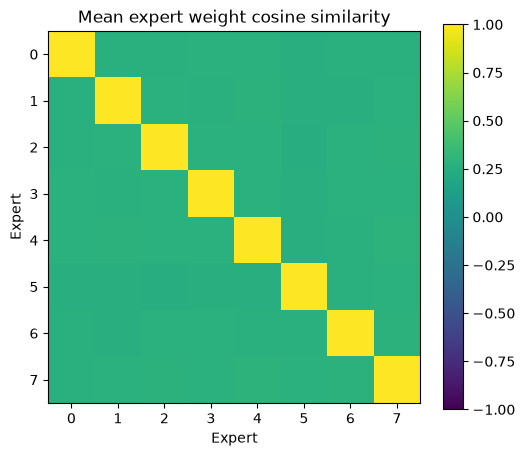

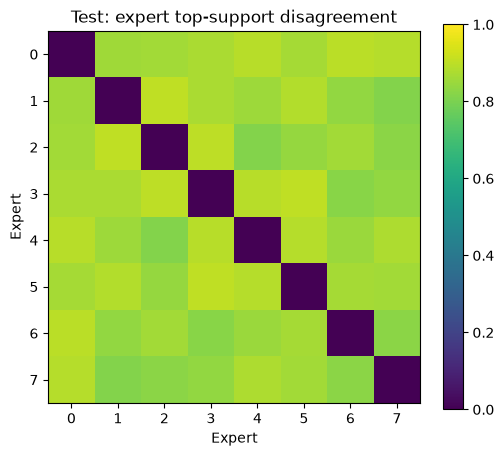

In [5]:
display(expert_summary.round(4))

mean_weight = weight.groupby(['expert_a', 'expert_b'])['weight_cosine_similarity'].mean()
matrix = np.eye(8)
for (a, b), value in mean_weight.items():
    matrix[int(a), int(b)] = value
    matrix[int(b), int(a)] = value
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix, vmin=-1, vmax=1)
ax.set_xlabel('Expert')
ax.set_ylabel('Expert')
ax.set_title('Mean expert weight cosine similarity')
fig.colorbar(image, ax=ax)
plt.show()

test_func = functional[functional['split'] == 'test']
mean_func = test_func.groupby(['expert_a', 'expert_b'])['top_support_disagreement_rate'].mean()
matrix = np.zeros((8, 8))
for (a, b), value in mean_func.items():
    matrix[int(a), int(b)] = value
    matrix[int(b), int(a)] = value
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix, vmin=0, vmax=1)
ax.set_xlabel('Expert')
ax.set_ylabel('Expert')
ax.set_title('Test: expert top-support disagreement')
fig.colorbar(image, ax=ax)
plt.show()

## Interpretation guide

- If lower temperature improves validation BA and increases Ordered-minus-shuffled while expert functional diversity is already substantial, the next experiment should target routing sharpness.
- If expert weight/evidence similarity is high and sharpening provides little benefit, the next experiment should target expert specialization or reduce K.
- If hard routing hurts while moderate sharpening helps, preserve soft transitions and use a controlled temperature rather than one-hot state assignment.
- Test results here remain post-hoc diagnostics; this notebook does not select a new deployable temperature or architecture.